In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.svm import SVC

X,y=datasets.make_blobs(
    n_samples=200,
    centers=2,
    random_state=42,
    cluster_std=1.1
)

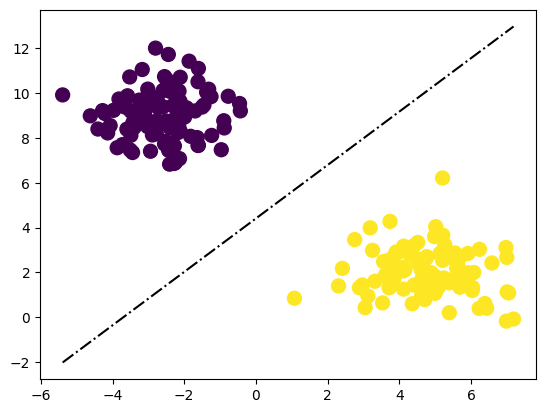

In [70]:
svm=SVC(kernel='linear',C=10)
svm.fit(X,y)

w=svm.coef_[0]
b=svm.intercept_[0]

def decision_line(X):
  return -(w[0]*X+b)/w[1]

plt.scatter(X[:,0],X[:,1],c=y,s=100)

x_value=np.linspace(X[:,0].min(),X[:,0].max(),100)
y_value=decision_line(x_value)
plt.plot(x_value,y_value,color='black',linestyle='dashdot')

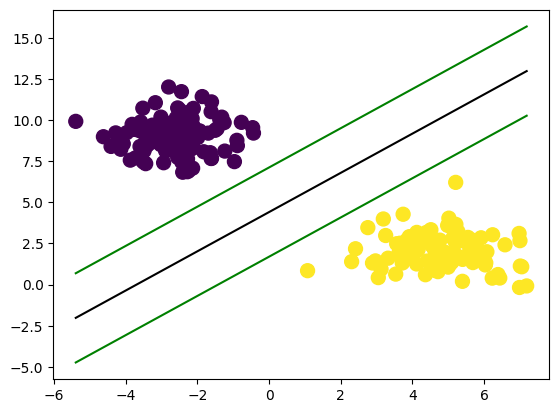

In [71]:
margin=1/np.linalg.norm(w)
y_value=decision_line(x_value)
morgin_pos=y_value+margin
morgin_neg=y_value-margin
plt.scatter(X[:,0],X[:,1],c=y,s=100)
plt.plot(x_value,y_value,color='black')
plt.plot(x_value,morgin_pos,color='green')
plt.plot(x_value,morgin_neg,color='green')

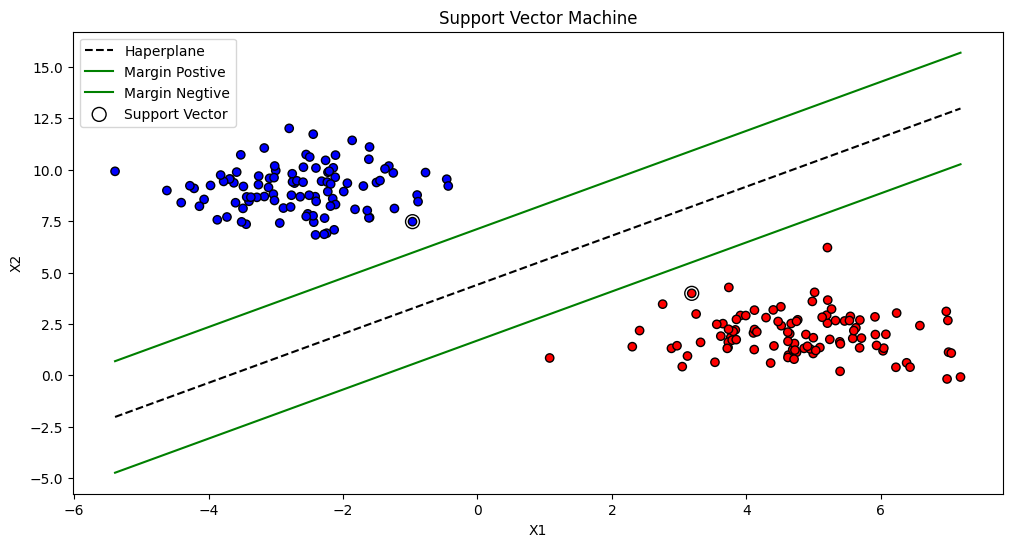

In [72]:
plt.figure(figsize=(12,6))
plt.scatter(X[:,0],X[:,1],edgecolors='k',c=y,cmap='bwr')
plt.plot(x_value,y_value,color='black', linestyle='--',label='Haperplane')
#Margin Postive
plt.plot(x_value,morgin_pos,color='green',label='Margin Postive')
#Margin Negtive
plt.plot(x_value,morgin_neg,color='Green',label='Margin Negtive')

#HighLight Support vector

plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=100,
    edgecolors='black',
    facecolors='none',
    label='Support Vector'
)

plt.title('Support Vector Machine')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [73]:
print(f"Weight : {w}")
print(f"Bias : {b}")
print(f"Margin (1/||w||) : {margin}")
print(f"Number of Support vector : {len(svm.support_vectors_)}")

Weight : [ 0.28261412 -0.23707804]
Bias : 1.0445466066991622
Margin (1/||w||) : 2.710866037497649
Number of Support vector : 2


Kernal Tricks

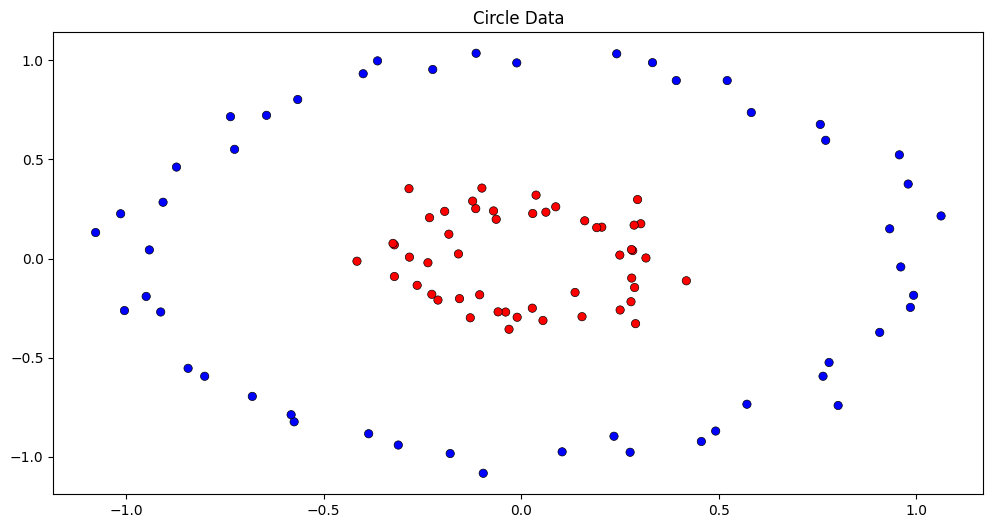

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X,y=make_circles(n_samples=100,factor=0.3,noise=0.05,random_state=42)

plt.figure(figsize=(12,6))
sns.scatterplot(x=X[:,0], y=X[:,1], c=y, cmap='bwr', edgecolors='k')
plt.title('Circle Data')
plt.show()

In [75]:
kernals={
    'Linear' : SVC(kernel='linear',C=10),
    'Polynomial' : SVC(kernel='poly',degree=3),
    'RBF' : SVC(kernel='rbf',gamma=1.5),
    'Sigmoid' : SVC(kernel='sigmoid',gamma=1.5)
}

for name,model in kernals.items():
  model.fit(X,y)
  y_pred=model.predict(X)
  accuracy=accuracy_score(y,y_pred)
  print(f"{name} Accuracy : {accuracy}")


Linear Accuracy : 0.67
Polynomial Accuracy : 0.6
RBF Accuracy : 1.0
Sigmoid Accuracy : 0.67


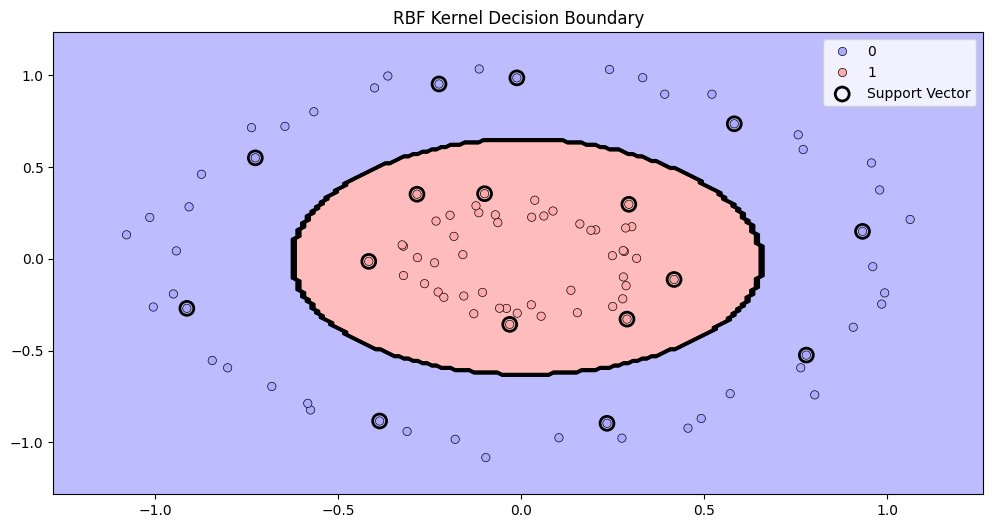

In [76]:
# RBF model ko dictionary se nikaal rahe hain
rbf_model = kernals['RBF']


# Pura graph cover karne ke liye grid bana rahe hain
xx, yy = np.meshgrid(

    # X-axis ke points
    np.linspace(
        X[:,0].min() - 0.2,   # sabse chhoti x value
        X[:,0].max() + 0.2,   # sabse bari x value
        200                   # total 200 points
    ),

    # Y-axis ke points
    np.linspace(
        X[:,1].min() - 0.2,   # sabse chhoti y value
        X[:,1].max() + 0.2,   # sabse bari y value
        200
    )
)


# Grid ko ek proper format me convert kar rahe hain
grid = np.c_[xx.ravel(), yy.ravel()]


# Har grid point par model prediction le rahe hain
pred = rbf_model.predict(grid)


# Prediction ko wapas grid shape me la rahe hain
pred = pred.reshape(xx.shape)


# Graph ka size set kar rahe hain
plt.figure(figsize=(12,6))


# Background me decision regions show kar rahe hain
plt.contourf(
    xx,
    yy,
    pred,
    alpha=0.3,
    cmap='bwr'
)


# Decision boundary ki black line draw kar rahe hain
plt.contour(
    xx,
    yy,
    pred,
    colors='black'
)


# Original data points show kar rahe hain
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    hue=y,
    palette='bwr',
    edgecolor='k'
)


# Support vectors ko alag highlight kar rahe hain
plt.scatter(

    rbf_model.support_vectors_[:,0],
    rbf_model.support_vectors_[:,1],

    s=100,

    edgecolors='black',

    facecolors='none',

    linewidths=2,

    label='Support Vector'
)


# Graph ka title
plt.title('RBF Kernel Decision Boundary')


# Legend show karna
plt.legend()


# Final graph display karna
plt.show()

In [77]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics  import accuracy_score

In [78]:
X,y=make_classification(
    n_samples=1000,
    n_features=100,
    n_informative=15,
    n_redundant=10,
    n_repeated=10,
    # n_classes=2,
    random_state=42
)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42) \

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"X Orignal Shape: {X.shape}")

X_train shape : (800, 100)
X_test shape : (200, 100)
X Orignal Shape: (1000, 100)


In [79]:
svm_baseline=SVC(kernel='rbf',C=10)  # Weak Regularzition
svm_baseline.fit(X_train,y_train)
y_pred_baseline=svm_baseline.predict(X_test)
accuracy_baseline=accuracy_score(y_test,y_pred_baseline)
print(f"Baseline Accuracy : {accuracy_baseline}")

Baseline Accuracy : 0.935


In [80]:
svm_reg=SVC(kernel='rbf',C=1)  # Strong Regularzition
svm_reg.fit(X_train,y_train)
y_pred_reg=svm_reg.predict(X_test)
accuracy_reg=accuracy_score(y_test,y_pred_reg)
print(f"Regularized Accuracy : {accuracy_reg}")

Regularized Accuracy : 0.905


In [90]:
pca=PCA(n_components=10)
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)
svm_pca=SVC(kernel='rbf',C=10)
svm_pca.fit(X_train_pca,y_train)
y_pred_pca=svm_pca.predict(X_test_pca)
accuracy_pca=accuracy_score(y_test,y_pred_pca)
print(f"PCA Accuracy : {accuracy_pca}")

PCA Accuracy : 0.85


In [91]:
selector=SelectKBest(score_func=f_classif,k=20)
X_train_selected=selector.fit_transform(X_train,y_train)
X_test_selected=selector.transform(X_test)
svm_selected=SVC(kernel='rbf',C=10)
svm_selected.fit(X_train_selected,y_train)
y_pred_selected=svm_selected.predict(X_test_selected)
accuracy_selected=accuracy_score(y_test,y_pred_selected)
print(f"Selected Features Accuracy : {accuracy_selected}")

Selected Features Accuracy : 0.9
